# 6회차 · 첫 신경망 — 딥러닝으로 손글씨 숫자 분류 (미니 프로젝트)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KimKangSoo123/Github_Colab_Integration_Practice/blob/main/week6/06_deep_learning_KKS.ipynb)

**오늘의 목표 (약 3시간)**
- 신경망의 아주 기본 개념 (층 · 활성화 함수 · 학습(epoch))
- Keras(TensorFlow)로 작은 신경망 만들기
- 손글씨 숫자(MNIST) 분류를 끝까지 돌려보기
- 층/epoch를 바꿔보며 결과 비교 → 팀 회고

> 🎯 오늘은 "원리 정복"이 아니라 **동작하는 딥러닝 모델을 처음부터 끝까지 돌려봤다**는 성취가 목표입니다. 수학은 이후 심화 과정에서!

> ⚡ Colab 메뉴 `런타임 → 런타임 유형 변경` 에서 **GPU** 를 선택하면 학습이 더 빠릅니다.

*   신경망의 기본 개념 	: 입력값을 받아 계산하고 결과를 내는 구조
    - 층 (Layers) :
* 입력층 : 바깥에서 처음 데이터를 받는 곳입니다.
* 은닉층 : 입력과 출력 사이에서 복잡한 패턴을 찾고 계산합니다.
* 출력층 : 최종 결과나 답을 만들어 냅니다.
    - 활성화 함수 (Activation Function) : 네트워크가 단순한 직선 모양이 아니라 복잡한 문제를 풀 수 있도록 이전 층에서 받은 신호를 그대로 보낼지 아니면 크기를 바꿀지 결정
    - 에포크(epoch) 		: 가지고 있는 전체 학습 데이터를 신경망이 한 번 전부 다 훑어본 횟수로 1 에포크는 모든 데이터로 예측해 보고 틀린 만큼 고치는 과정을 한 바퀴 끝낸 상태

*   Keras(TensorFlow) 	: TensorFlow 위에서 작동하는 고수준 딥러닝 API로 복잡한 TensorFlow 연산을 단순화하여 인공신경망 모델을 쉽게 만들고 실행할 수 있게 돕는 파이썬 라이브러리
    - 텐서플로(TensorFlow) 	: 구글이 개발한 오픈소스 머신러닝(기계학습) 및 딥러닝(심층학습) 라이브러리
    - API : 서로 다른 소프트웨어 프로그램들이 서로 대화하고 데이터를 주고받을 수 있게 도와주는 규칙과 방법(통로)

*   손글씨 숫자(MNIST) 	: 0부터 9까지의 숫자를 사람이 직접 쓴 7만 개의 흑백 이미지로 구성된 인공지능 분야의 가장 기초적인 인식 모델 시험용 데이터 모음(벤치마크 데이터셋)

---
## 0. MNIST 데이터 불러오기

MNIST는 0~9 손글씨 숫자 이미지 7만 장입니다. 딥러닝 입문의 "Hello World"예요. 각 이미지는 28×28 픽셀입니다.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
학습 이미지: (60000, 28, 28)
테스트 이미지: (10000, 28, 28)


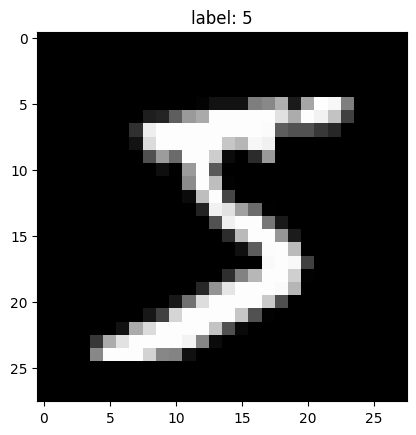

In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("학습 이미지:", X_train.shape)   # (60000, 28, 28)
print("테스트 이미지:", X_test.shape)

# 첫 이미지 하나 그려보기
plt.imshow(X_train[0], cmap="gray")
plt.title(f"label: {y_train[0]}")
plt.show()

*   matplotlib.pyplot 	: 파이썬에서 데이터를 그림이나 그래프로 쉽게 보여주기(시각화) 위해 matplotlib 라이브러리의 pyplot 모듈을 불러옴.

*   keras.datasets.mnist.load_data() : 손글씨 숫자 이미지 데이터셋인 MNIST를 다운로드하고 불러오는 케라스(Keras) 함수
 -> 훈련용과 테스트용 데이터로 나누어 저장

*   MNIST의 X_train : 3차원 배열로 (이미지 개수, 이미지의 세로 픽셀 수, 이미지의 가로 픽셀 수) -> 이미지 한 장은 28행 × 28열 행렬

*   plt.imshow(X_train[0], cmap="gray") : 파이썬의 시각화 도구인 Matplotlib 라이브러리를 사용해 훈련 데이터셋(X_train)의 60,000장 중 첫 번째 이미지([0])에 해당하는 (28, 28) 배열을 흑백(Grayscale) 화면으로 그려주는(출력하는) 코드
    - X_train[0] : 그림 파일 자체라기보다 다음과 같은 숫자 행렬
    - plt.imshow() : 파이썬 라이브러리 Matplotlib에서 "2차원 배열 데이터"나 이미지 파일을 화면에 그림(이미지) 형태로 보여주는 함수



---
## 1. 전처리 — 스케일링 (또 등장!)

픽셀 값은 0~255입니다. 5회차에서 배운 대로, 신경망도 0~1 범위를 좋아해요. 255로 나눠 정규화합니다. (1회차의 정규화가 마지막까지 따라옵니다!)

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("최소:", X_train.min(), " 최대:", X_train.max())

최소: 0.0  최대: 1.0


*   정규화 (Normalization) : 데이터의 값 범위를 0과 1 사이로 바꾸는 작업(Min-Max Scaling)
    - 공식 	: (𝑥−min)/(max−min)
    - 특징 	: 가장 작은 값은 0, 가장 큰 값은 1이 되며 데이터의 상대적인 분포 형태를 유지한 채 크기만 줄임
    - 사용 시기 	: 데이터의 최소값과 최대값을 명확히 알고 있고 "신경망" 등에서 입력 값의 범위를 맞추고 싶을 때 사용

*   표준화 (Standardization) : 데이터의 평균을 0, 표준편차(분산)를 1로 만드는 작업(Z-score Scaling)
    - 공식 	: (𝑥−mean)/(std)
    - 특징 	: 데이터가 평균 0을 중심으로 좌우에 대칭적으로 분포하도록 바꾸고 이상치(Outlier)의 영향을 비교적 크게 받을 수 있음
    - 사용 시기 	: 주성분 분석(PCA)이나 서포트 벡터 머신(SVM), "선형 회귀" 등 데이터의 평균과 분산이 중요할 때 사용

*   (max−min)가 255인 이유 	: 8비트 이미지에서는 하나의 픽셀이 표현할 수 있는 값이 총 256개로 MNIST 픽셀값의 최솟값이 0, 최댓값이 255임

*   255.0처럼 소수로 쓰는 이유 	: 255.0을 사용하면 결과가 실수형으로 변환

### 🔧 과제 1-1
`X_train` 의 두 번째 이미지(`X_train[1]`)를 그리고 제목에 정답을 넣으세요.

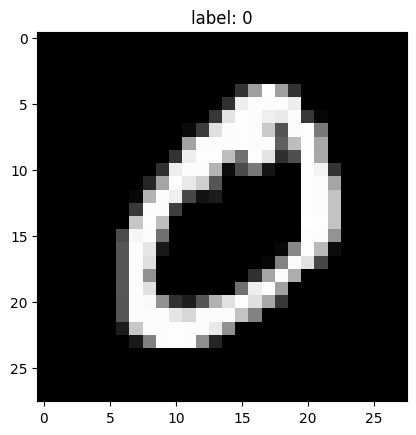

In [4]:
# TODO
plt.imshow(X_train[1], cmap="gray")
plt.title(f"label: {y_train[1]}")
plt.show()

---
## 2. 신경망 모델 만들기

작은 신경망을 쌓습니다.
- `Flatten`: 28×28 이미지를 784개 숫자 한 줄로 펼침
- `Dense(128, relu)`: 뉴런 128개 층. relu는 활성화 함수(신호를 통과시킬지 결정)
- `Dense(10, softmax)`: 마지막 층. 0~9 각각일 확률 10개를 출력

*   Dense(128, relu)
    - Dense 	: 이전 층의 모든 뉴런과 현재 층의 모든 뉴런이 서로 빽빽하게 연결된 밀집층
    - 128 	: 층에 있는 뉴런의 개수로 데이터를 받아 처리하고 다음으로 넘겨주는 계산 단위를 128개 사용한다는 뜻이며 데이터의 특징을 "128가지 방향으로 추출"
    - relu 	: 0보다 작은 값이 들어오면 0을 내보내고 0보다 큰 값이 들어오면 그 값 그대로 내보내는 활성화 함수로 신경망이 복잡한 문제를 풀 수 있도록 비선형성을 더해줌

*   Dense(10, softmax)
    - 10 : 출력 노드의 개수가 10개임을 뜻하고 10가지 결과 중 하나로 분류할 때 사용
    - softmax (소프트맥스) : 출력값을 0과 1 사이의 확률 값으로 바꿔주며 10개 값의 총합이 정확히 1이 되도록 만들어주는 활성화 함수

In [6]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

*   keras.Sequential 		: 딥러닝 모델의 층(layer)을 입력층부터 출력층까지 차례대로 순서대로 쌓아 올리는 Sequential 모델

*   model.compile 		: 딥러닝 모델을 학습시키기 전에 필요한 학습 환경과 방식을 설정하는 단계
    - optimizer="adam" : 널리 쓰이는 아담(Adam) "최적화 알고리즘(방법)"으로 모델이 학습할 때 틀린 정도를 보고 가중치를 똑똑하고 빠르게 고쳐줌
    - loss="sparse_categorical_crossentropy" : 정답 레이블이 원-핫 인코딩이 아닌 정수(0, 1, 2 등) 형태일 때 사용하는 "교차 엔트로피 손실 함수"입니다.모델이 예측한 값과 실제 정답의 차이를 계산해 틀린 정도를 알려줌.
    - metrics=["accuracy"] : 학습 과정에서 모델이 얼마나 잘 맞추는지 정확도(Accuracy)를 눈으로 확인하기 위한 "평가 지표"

*   model.summary() 	: 인공신경망 모델의 구조, 각 층(Layer)의 이름과 형태(Output Shape), 그리고 학습할 매개변수(Param #)의 개수를 화면에 요약해서 보여주는 텐서플로우/케라스(TensorFlow/Keras) 메서드

---
## 3. 학습(fit) — epoch 만큼 반복

**epoch** 는 전체 데이터를 몇 번 반복 학습할지입니다. 5번 돌려봅니다. 학습이 진행되며 정확도가 오르는 걸 지켜보세요.

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.1,   # 학습 데이터의 10%로 중간 검증
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.9810 - val_loss: 0.0818
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9965 - loss: 0.0116 - val_accuracy: 0.9808 - val_loss: 0.0903
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9972 - loss: 0.0095 - val_accuracy: 0.9793 - val_loss: 0.1007
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9972 - loss: 0.0098 - val_accuracy: 0.9783 - val_loss: 0.0988
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9977 - loss: 0.0077 - val_accuracy: 0.9803 - val_loss: 0.0937


*   validation_split=0.1 	: 전체 훈련 데이터 중 10%를 검증 데이터(Validation Data)로 분리하고 나머지 90%를 모델 학습(Training)에 사용하는 케라스(Keras) 및 텐서플로우(TensorFlow)의 매개변수
    - 에포크마다 새로운 10%를 다시 뽑는 것이 아니라 한 번 분리된 동일한 검증 데이터를 매 에포크 평가에 사용

*   epochs=5 			: 같은 모델이 이전 에포크에서 학습한 가중치를 유지한 채 학습 데이터를 총 5회 반복

*   학습 정확도(accuracy) 		: 0.9207 → 0.9853 증가
*   학습 손실(loss) 			: 0.2747 → 0.0478 감소
*   검증 정확도(val_accuracy) 	: 0.9623 → 0.9775 증가
*   검증 손실(val_loss) 		: 0.1322 → 0.0823 감소
    - 모델은 손실함수의 값을 줄이는 방향으로 학습데이터에 대한 가중치를 업데이트하여 검증에 적용
* -> epoch 1의 val_accuracy와 epoch 2의 accuracy이 동일하지 않은 이유 :
    - 평가한 데이터가 다름 	: val_accuracy는 검증 데이터, accuracy는 학습 데이터에서 계산
    - 가중치 상태가 다름 	: epoch 1의 검증에서는 가중치가 고정되지만 epoch 2 학습에서는 배치마다 가중치가 바뀜.



---
## 4. 평가 & 예측

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 정확도: {test_acc:.4f}")

테스트 정확도: 0.9765


*   model.evaluate() : 훈련된 인공지능 모델의 성능을 평가하는 함수로 손실값(loss)과 정확도(accuracy) 같은 지표를 계산
    - verbose=0 : 프로그램이나 함수가 실행될 때 진행 상황이나 상세한 로그(Log) 메시지를 화면에 출력하지 않도록(숨기도록) 설정하는 옵션 값

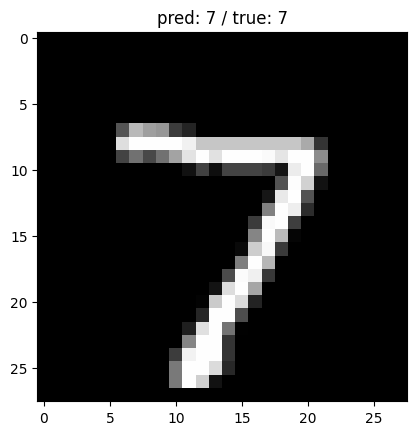

In [9]:
import numpy as np

# 테스트 이미지 하나 예측
idx = 0
pred = model.predict(X_test[idx:idx+1], verbose=0)
predicted = np.argmax(pred)   # 확률이 가장 높은 숫자

plt.imshow(X_test[idx], cmap="gray")
plt.title(f"pred: {predicted} / true: {y_test[idx]}")
plt.show()

*   dx:idx+1(슬라이싱) : 콜론(:)을 사용해 시작 위치부터 끝 위치 전까지의 부분 집합을 가져옴

*   np.argmax() : 파이썬 넘파이(NumPy) 라이브러리에서 제공하는 함수로 배열에서 가장 큰 값이 있는 위치(인덱스)를 찾아줌
    - model를 정의할 때 "keras.layers.Dense(10, activation="softmax")"로 인해 10개의 값 중 1개의 확률이 가장 높은 숫자를 뽑는다

### 🔧 과제 4-1
학습 과정의 정확도 변화를 그래프로 그리세요. epoch가 늘수록 오르는 모습을 볼 수 있어요.

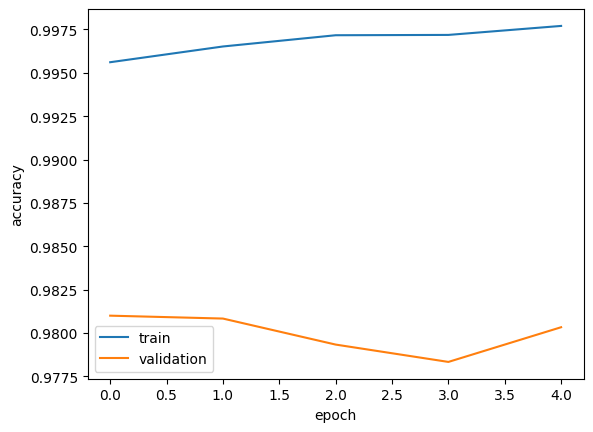

In [17]:
# TODO: history.history 에서 'accuracy' 를 꺼내 그리세요
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

*   .history[""] : 프로그래밍에서 이전 기록이나 상태를 담은 history 객체(또는 딕셔너리)에서 빈 문자열("") 키에 저장된 값을 가져오는 코드

*   plt.legend() : 파이썬 시각화 라이브러리인 맷플롯립(Matplotlib)에서 그래프에 범례(legend)를 표시해 주는 함수

---
## 🎯 오늘의 미니 프로젝트 (제출용)

**모델을 바꿔가며 실험하고, 결과를 비교하세요.** 아래 중 하나 이상을 바꿔 새 모델을 학습시키고 테스트 정확도를 기록합니다.
- 은닉층 뉴런 수 (128 → 256 등)
- 층을 하나 더 추가
- epoch 수 (5 → 10 등)

In [11]:
# 예시 틀 — 자유롭게 수정하세요
my_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    # TODO: 층을 바꾸거나 추가해보세요
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
my_model.compile(optimizer="adam",
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

my_model.fit(X_train, y_train, epochs=10, validation_split=0.1)

my_loss, my_acc = my_model.evaluate(X_test, y_test, verbose=0)
print(f"내 모델 테스트 정확도: {my_acc:.4f}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9301 - loss: 0.2424 - val_accuracy: 0.9647 - val_loss: 0.1180
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9711 - loss: 0.0981 - val_accuracy: 0.9733 - val_loss: 0.0860
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9796 - loss: 0.0670 - val_accuracy: 0.9748 - val_loss: 0.0830
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9852 - loss: 0.0479 - val_accuracy: 0.9790 - val_loss: 0.0763
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9892 - loss: 0.0337 - val_accuracy: 0.9790 - val_loss: 0.0768
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9921 - loss: 0.0266 - val_accuracy: 0.9757 - val_loss: 0.0867
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9934 - loss: 0.0205 - val_accuracy: 0.9783 - val_loss: 0.0758
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9946 - loss: 0.0175 - 

**📝 팀 회고 (더블클릭해서 편집):**
- 무엇을 바꿨나요?
- 정확도는 어떻게 달라졌나요? (기본 모델 대비)
- 2주 스터디에서 가장 기억에 남는 것 한 가지:
- 궁금한 점 : 학습 후 검증하는 단계에서는 학습동안의 가중치를 개선하는 단계로 알고 있는데 왜 학습 후 정확도보다 검증 후 정확도가 더 떨어지는가(여러 번 실행할 경우 하락 폭이 더 커짐.)


---
## 🎉 2주 스터디 완주!

파이썬 기초 → NumPy → pandas → 머신러닝 → 평가 → 딥러닝까지, 전 과정을 한 번 관통했습니다. 여기서부터의 심화(수학적 원리, 더 큰 모델, 다양한 데이터)는 이 토대 위에서 훨씬 수월할 거예요.

**제출 방법**
1. `런타임 → 모두 실행`
2. `파일 → GitHub에 사본 저장` → `members/본인이름/06_deep_learning.ipynb`
3. 커밋 메시지: `6회차 완료 🎉`
